In [1]:
# ppo 实现

# actor-critic的实现

import gym
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def show_animation(imgs):
    rc("animation", html="jshtml")
    fig, ax = plt.subplots(1, 1, figsize=(5, 3))
    frames = []

    text = ax.text(10, 20, "", fontsize=12, color="black")

    for i, img in enumerate(imgs):
        frame = [ax.imshow(img, animated=True)]
        frame.append(ax.text(10, 20, f"Step: {i + 1}", animated=True))  # Step数表示
        frames.append(frame)

    ax.axis("off")

    ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

    # 保存动画
    # ani.save("cartpole.mp4", writer="ffmpeg")
    ani.save("cartpole.gif", writer="pillow")

    plt.close(fig)
    return ani


def plot_loss(episode_list, return_list, filename):
    """绘制奖励图像"""
    f = plt.figure()
    plt.plot(episode_list, return_list)
    plt.xlabel("Episodes")
    plt.ylabel("Returns")
    plt.title("CartPole-v0")
    plt.show()
    f.savefig(filename, bbox_inches="tight")


class PolicyNet(nn.Module):
    """策略神经网络的结构"""

    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):  # x是S_t
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=1)
        return x


class ValueNet(nn.Module):
    """价值函数神经网络V_ω"""

    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr_pi = 0.001
        self.lr_v = 0.02
        self.action_size = 2
        self.pi = PolicyNet(self.action_size)
        self.v = ValueNet()
        self.optimizer_pi = optim.Adam(self.pi.parameters(), lr=self.lr_pi)
        self.optimizer_v = optim.Adam(self.v.parameters(), lr=self.lr_v)

    def get_action(self, state):
        probs = self.pi(torch.tensor(state).unsqueeze(0)).squeeze(0)
        m = Categorical(probs)
        action = m.sample().item()
        return action, probs

    def collect_trajectory(self, env):
        """采样一条轨迹"""
        state = env.reset()
        states, next_states, actions, action_probs, rewards, dones = [], [], [], [], [], []
        done = False

        while not done:
            action, probs = self.get_action(state)
            next_state, reward, done, _ = env.step(action)

            states.append(state)  # S_t
            next_states.append(next_state)  # S_(t+1)
            actions.append(action)  # A_t
            action_probs.append(probs[action])  # π_old(a_t|s_t)
            rewards.append(reward)  # R_t
            dones.append(done)  # done_t

            state = next_state

        # states: [S_0, S_1, S_2, ..., S_(T-1)]
        # next_states: [S_1, S_2, S_3, ..., S_T]
        # actions: [A_0, A_1, A_2, ..., A_(T-1)]
        # rewards: [R_0, R_1, R_2, ..., R_(T-1)]
        # dones: [False, False, False, ..., True]
        return states, next_states, actions, action_probs, rewards, dones

    def update(self, trajectory):
        """整条轨迹的ppo更新"""
        states, next_states, actions, action_probs, rewards, dones = trajectory

        states = torch.tensor(states)
        next_states = torch.tensor(next_states)
        actions = torch.tensor(actions).view(-1, 1)
        rewards = torch.tensor(rewards).view(-1, 1)
        dones = torch.tensor(dones, dtype=torch.float).view(-1, 1)

        # V(S_t)构成的数组
        v = self.v(states).detach()
        # td target = R_t + γV(S_(t+1))
        td_target = rewards + self.gamma * self.v(next_states) * (1 - dones)
        # δ_t组成的数组
        td_delta = td_target - v
        # 每一个时间步的广义优势估计构成的数组
        gae = self.compute_gae(td_delta.cpu())

        # 冻结一份旧策略产生的轨迹中动作的对数概率：log π_old(a_t|s_t)
        old_probs = torch.tensor(action_probs).view(-1, 1)
        old_log_probs = torch.log(old_probs).detach()

        for _ in range(10):
            # 正在训练的新策略采取动作的对数概率: log π_θ(a_t|s_t)
            log_probs = torch.log(self.pi(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)

            surr1 = ratio * gae
            surr2 = torch.clamp(ratio, 0.8, 1.2) * gae

            loss_pi = torch.mean(-torch.min(surr1, surr2))
            loss_v = F.mse_loss(self.v(states), gae + v)

            self.optimizer_pi.zero_grad()
            self.optimizer_v.zero_grad()
            loss_v.backward()
            loss_pi.backward()
            self.optimizer_pi.step()
            self.optimizer_v.step()

    def compute_gae(self, td_delta):
        td_delta = td_delta.detach().numpy()
        gae_list = []
        last_gae = 0.0
        lmbda = 0.95
        # GAE_t = δ_t + γλGAE_(t+1)
        for delta in td_delta[::-1]:
            last_gae = delta + self.gamma * lmbda * last_gae
            gae_list.append(last_gae)
        gae_list.reverse()
        return torch.tensor(gae_list)

C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated an

回合：0, 总奖励：32.0
回合：10, 总奖励：17.0
回合：20, 总奖励：28.0
回合：30, 总奖励：103.0
回合：40, 总奖励：93.0
回合：50, 总奖励：200.0
回合：60, 总奖励：200.0
回合：70, 总奖励：200.0
回合：80, 总奖励：200.0
回合：90, 总奖励：200.0
回合：100, 总奖励：200.0
回合：110, 总奖励：200.0
回合：120, 总奖励：200.0
回合：130, 总奖励：200.0
回合：140, 总奖励：200.0
回合：150, 总奖励：200.0
回合：160, 总奖励：65.0
回合：170, 总奖励：200.0
回合：180, 总奖励：200.0
回合：190, 总奖励：200.0
回合：200, 总奖励：200.0
回合：210, 总奖励：200.0
回合：220, 总奖励：200.0
回合：230, 总奖励：200.0
回合：240, 总奖励：200.0
回合：250, 总奖励：200.0
回合：260, 总奖励：200.0
回合：270, 总奖励：200.0
回合：280, 总奖励：200.0
回合：290, 总奖励：200.0
回合：300, 总奖励：200.0
回合：310, 总奖励：200.0
回合：320, 总奖励：200.0
回合：330, 总奖励：200.0
回合：340, 总奖励：200.0
回合：350, 总奖励：200.0
回合：360, 总奖励：200.0
回合：370, 总奖励：200.0
回合：380, 总奖励：200.0
回合：390, 总奖励：200.0
回合：400, 总奖励：200.0
回合：410, 总奖励：200.0
回合：420, 总奖励：200.0
回合：430, 总奖励：200.0
回合：440, 总奖励：200.0
回合：450, 总奖励：200.0
回合：460, 总奖励：200.0
回合：470, 总奖励：200.0
回合：480, 总奖励：200.0
回合：490, 总奖励：200.0


C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


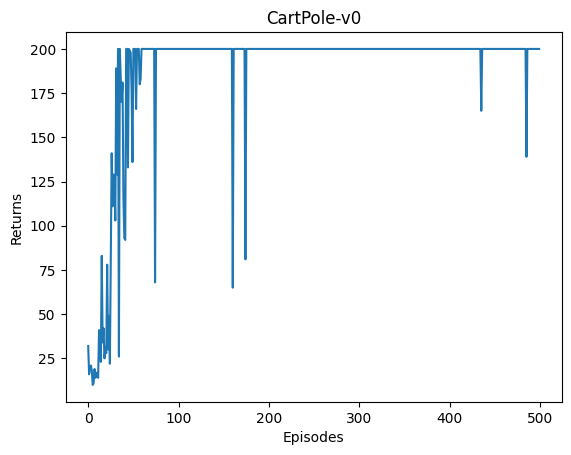

In [3]:
env = gym.make("CartPole-v0")
env.seed(42)
torch.manual_seed(42)
agent = Agent()
return_list = []
episode_list = []

for episode in range(500):
    trajectory = agent.collect_trajectory(env)
    # 采样一条轨迹，更新一次策略网络和价值网络
    agent.update(trajectory)

    return_list.append(sum(trajectory[4]))
    episode_list.append(episode)
    if episode % 10 == 0:
        print(f"回合：{episode}, 总奖励：{sum(trajectory[4])}")

plot_loss(episode_list, return_list, "ppo-loss.pdf")